Loading CIFAR-10 data for MLP...
Building the MLP model...


C:\Users\muham\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Training the model... (This will take a few minutes)
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.2520 - loss: 2.0283 - val_accuracy: 0.3064 - val_loss: 1.8681
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.2918 - loss: 1.9165 - val_accuracy: 0.3349 - val_loss: 1.8554
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3149 - loss: 1.8691 - val_accuracy: 0.3451 - val_loss: 1.8090
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.3237 - loss: 1.8345 - val_accuracy: 0.3653 - val_loss: 1.7772
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.3303 - loss: 1.8240 - val_accuracy: 0.3715 - val_loss: 1.7758
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.3404 - loss: 1.7986 - val_accuracy: 0.3804 - val_loss: 1.7610
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3442 - loss: 1.7961 - val_accuracy: 0.3691 - val_loss: 1.7623
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━

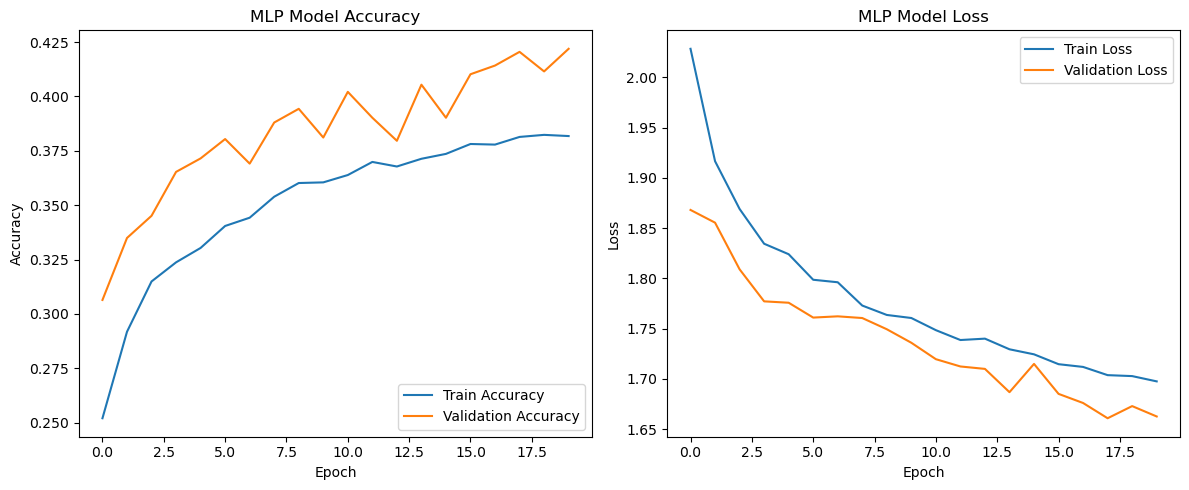

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import cifar10

# 1. Load and Preprocess Data
print("Loading CIFAR-10 data for MLP...")
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train_full.astype('float32') / 255.0
x_test = x_test_full.astype('float32') / 255.0

# Using full dataset for Neural Networks is recommended, 
# but you can slice it like x_train[:20000] if your PC is slow.
y_train = y_train_full.flatten()
y_test = y_test_full.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Define the Neural Network Architecture (MLP)
print("Building the MLP model...")
model_mlp = Sequential([
    # Flatten 32x32x3 images into a 1D array of 3072 pixels
    Flatten(input_shape=(32, 32, 3)),
    
    # First Hidden Layer with ReLU activation
    Dense(512, activation='relu'),
    
    # Dropout layer for regularization (prevents overfitting)
    Dropout(0.3),
    
    # Second Hidden Layer
    Dense(256, activation='relu'),
    Dropout(0.2),
    
    # Output Layer with Softmax (10 units for 10 classes)
    Dense(10, activation='softmax')
])

# 3. Compile the model
# Defining Loss, Optimizer, and Metrics
model_mlp.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_mlp.summary()

# 4. Train the model and save the history
print("Training the model... (This will take a few minutes)")
history = model_mlp.fit(x_train, y_train, 
                        epochs=20, 
                        batch_size=64, 
                        validation_split=0.2, # Use 20% of training data for validation
                        verbose=1)

# 5. Evaluate on Test Data
print("\nEvaluating on test data...")
test_loss, test_acc = model_mlp.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# 6. Plot Training and Validation Curves
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MLP Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MLP Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()